In [1]:
import random
import torch

import utils
import data_utils
import similarity

import matplotlib
from matplotlib import pyplot as plt

: 

## Settings

In [2]:
clip_name = 'ViT-B/16'
target_name = 'resnet50'
target_layer = 'layer4'
d_probe = 'imagenet_broden'
concept_set = 'data/3k.txt'
batch_size = 16
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'
similarity_fn = similarity.soft_wpmi

## Quantization

In [ ]:
import quantization_utils_awq

# Quantization settings
quantize_enabled = True  # Set to False to disable quantization
quantization_bits = 8    # INT8 quantization
quantization_group_size = 0  # 0 = per-channel, otherwise group-wise

In [ ]:
## Quantize Target Model (Optional)
if quantize_enabled:
    print(f"Loading {target_name} model for quantization...")
    original_model, _ = data_utils.get_target_model(target_name, device)
    
    print(f"Quantizing {target_name} with {quantization_bits}-bit AWQ quantization...")
    quantized_model = quantization_utils_awq.quantize_model_awq(
        original_model,
        num_bits=quantization_bits,
        device=device,
        quantize_linear=True,
        quantize_conv=True,
        group_size=quantization_group_size,
    )
    
    print(f"Model quantized successfully!")
    
    # Get model size statistics
    model_stats = quantization_utils_awq.get_quantized_model_size(quantized_model)
    print(f"Model size statistics:")
    print(f"  INT8 parameters: {model_stats['int8_params_mb']:.2f} MB")
    print(f"  FP32 equivalent: {model_stats['total_params_mb']:.2f} MB")
    print(f"  Compression ratio: {model_stats['compression_ratio']:.2f}x")
    
    # Use quantized model for subsequent operations
    target_model_to_use = quantized_model
else:
    print(f"Quantization disabled. Using original {target_name} model.")
    target_model_to_use = None  # Will load default in save_activations

In [ ]:
# Load models
clip_model, clip_preprocess = clip.load(clip_name, device=device)

if quantize_enabled and target_model_to_use is not None:
    # Use quantized model
    target_model = target_model_to_use
    target_preprocess = data_utils.get_target_model(target_name, device)[1]  # Get preprocessor only
else:
    # Load default model
    target_model, target_preprocess = data_utils.get_target_model(target_name, device)

# Setup data
data_c = data_utils.get_data(d_probe, clip_preprocess)
data_t = data_utils.get_data(d_probe, target_preprocess)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

# Ignore empty lines
words = [i for i in words if i != ""]

# Generate text embeddings
text = clip.tokenize(["{}".format(word) for word in words]).to(device)

# Get save names
save_names = utils.get_save_names(
    clip_name=clip_name,
    target_name=target_name,
    target_layer='{}',
    d_probe=d_probe,
    concept_set=concept_set,
    pool_mode=pool_mode,
    save_dir=save_dir
)

target_save_name, clip_save_name, text_save_name = save_names

# Save features using quantized model (if enabled)
print("Saving CLIP text features...")
utils.save_clip_text_features(clip_model, text, text_save_name, batch_size)

print("Saving CLIP image features...")
utils.save_clip_image_features(clip_model, data_c, clip_save_name, batch_size, device)

print(f"Saving target activations from {'quantized ' if quantize_enabled else ''}model...")
utils.save_target_activations(
    target_model,
    data_t,
    target_save_name,
    [target_layer],
    batch_size,
    device,
    pool_mode
)

print("Activation extraction complete!")


100%|██████████| 4202/4202 [01:37<00:00, 43.17it/s]


## Run CLIP-Dissect

In [ ]:
utils.save_activations(clip_name = clip_name, target_name = target_name, target_layers = [target_layer], 
                       d_probe = d_probe, concept_set = concept_set, batch_size = batch_size, 
                       device = device, pool_mode=pool_mode, save_dir = save_dir)

In [4]:
save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

similarities, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity_fn)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

100%|██████████| 2048/2048 [06:25<00:00,  5.31it/s]


torch.Size([2048, 3000])


## Visualize Results


 Layer:layer4 Neuron:292
1st description: music, sim:0.707
2nd description: musician, sim:0.591
3rd description: musical, sim:0.479
5 most highly activating images in D_probe:


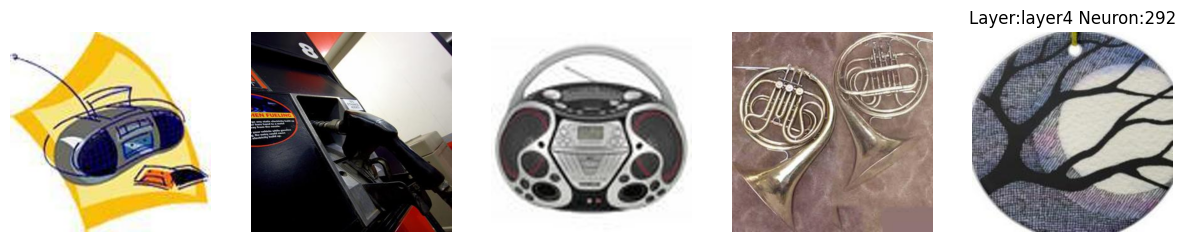


 Layer:layer4 Neuron:1060
1st description: animal, sim:0.962
2nd description: tail, sim:0.856
3rd description: African, sim:0.829
5 most highly activating images in D_probe:


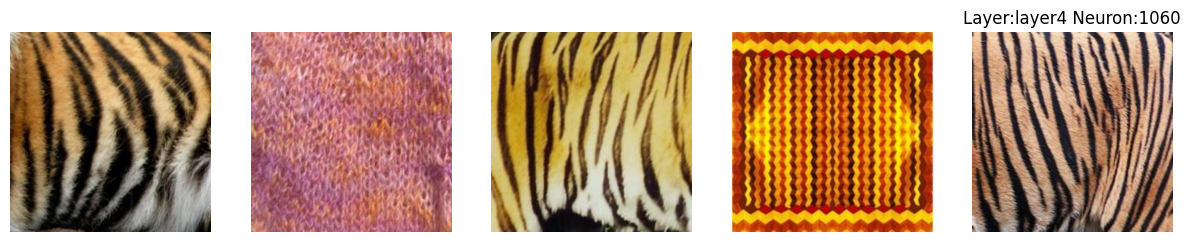


 Layer:layer4 Neuron:1376
1st description: nature, sim:1.879
2nd description: forest, sim:1.875
3rd description: green, sim:1.525
5 most highly activating images in D_probe:


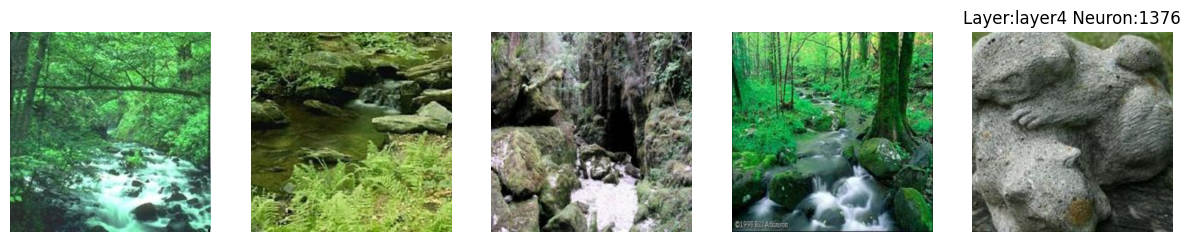


 Layer:layer4 Neuron:1678
1st description: dog, sim:1.142
2nd description: pet, sim:0.978
3rd description: asleep, sim:0.932
5 most highly activating images in D_probe:


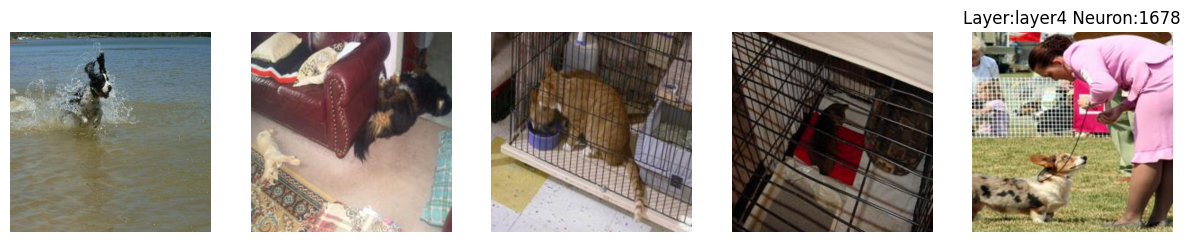


 Layer:layer4 Neuron:1981
1st description: pole, sim:0.628
2nd description: entrance, sim:0.618
3rd description: gate, sim:0.587
5 most highly activating images in D_probe:


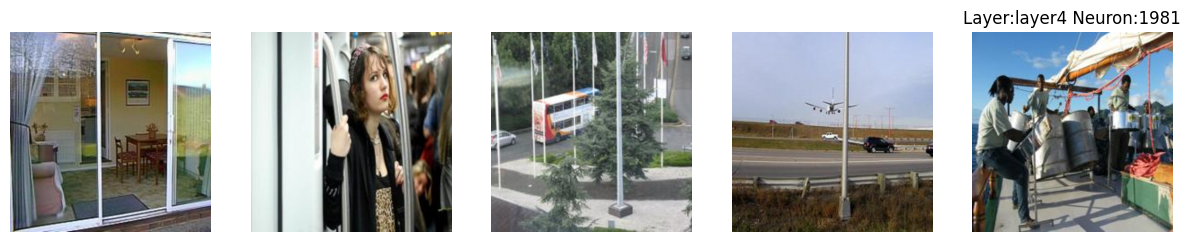


 Layer:layer4 Neuron:252
1st description: fence, sim:2.033
2nd description: net, sim:1.794
3rd description: wire, sim:1.349
5 most highly activating images in D_probe:


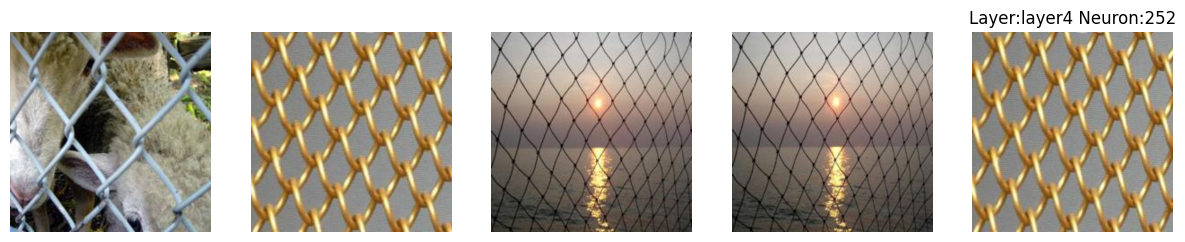


 Layer:layer4 Neuron:1759
1st description: grocery, sim:1.659
2nd description: store, sim:1.332
3rd description: selection, sim:1.305
5 most highly activating images in D_probe:


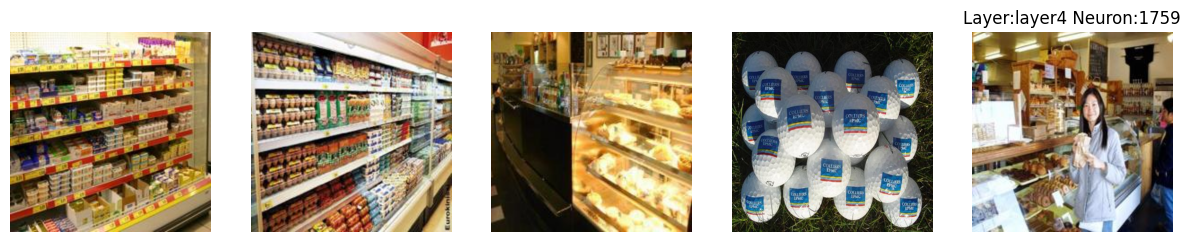


 Layer:layer4 Neuron:1167
1st description: stair, sim:2.959
2nd description: wheel, sim:1.711
3rd description: circumstance, sim:1.521
5 most highly activating images in D_probe:


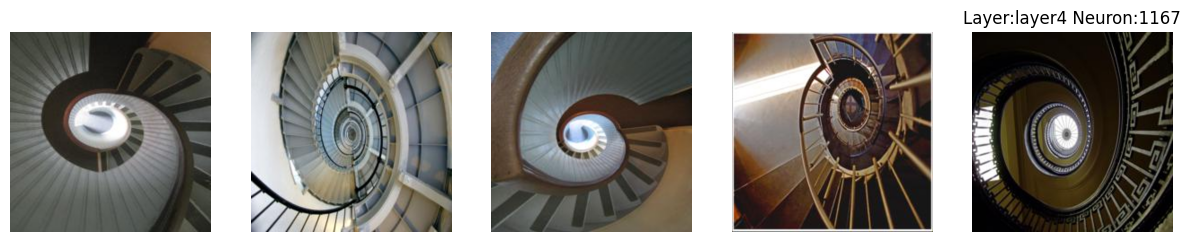


 Layer:layer4 Neuron:474
1st description: fence, sim:1.935
2nd description: farm, sim:1.220
3rd description: yard, sim:1.077
5 most highly activating images in D_probe:


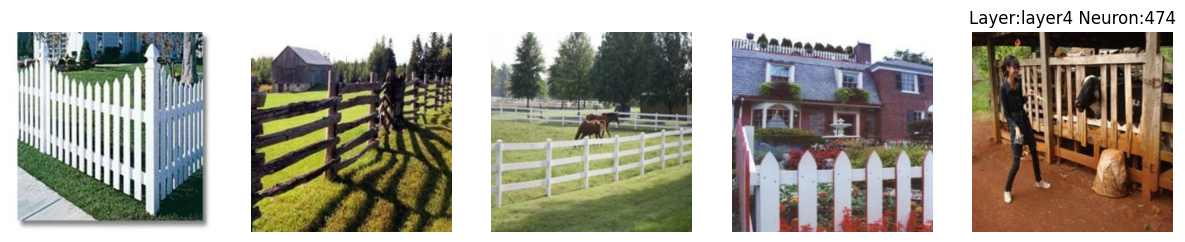


 Layer:layer4 Neuron:304
1st description: radio, sim:1.335
2nd description: tape, sim:1.216
3rd description: speaker, sim:1.013
5 most highly activating images in D_probe:


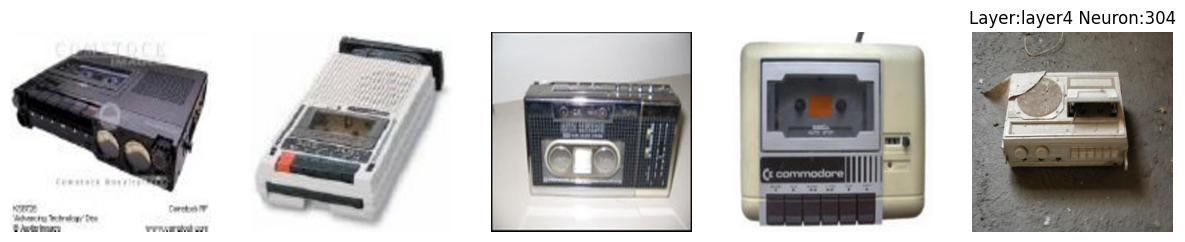

In [5]:
neurons_to_check = ids_to_check = random.sample([i for i in range(target_feats.shape[1])], k=10)
#neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]

ranks = ["1st", "2nd", "3rd"]
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

for orig_id in ids_to_check:

    print('\n Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    vals, ids = torch.topk(similarities[orig_id], k=3, largest=True)
    for i in range(len(vals)):
        print("{} description: {}, sim:{:.3f}".format(ranks[i], words[int(ids[i])], vals[i]))
    
    print("5 most highly activating images in D_probe:")
    fig = plt.figure(figsize=(15, 7))
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        fig.add_subplot(1, 5, i+1)
        plt.imshow(im)
        plt.axis('off')
        
    plt.title('Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    plt.show()

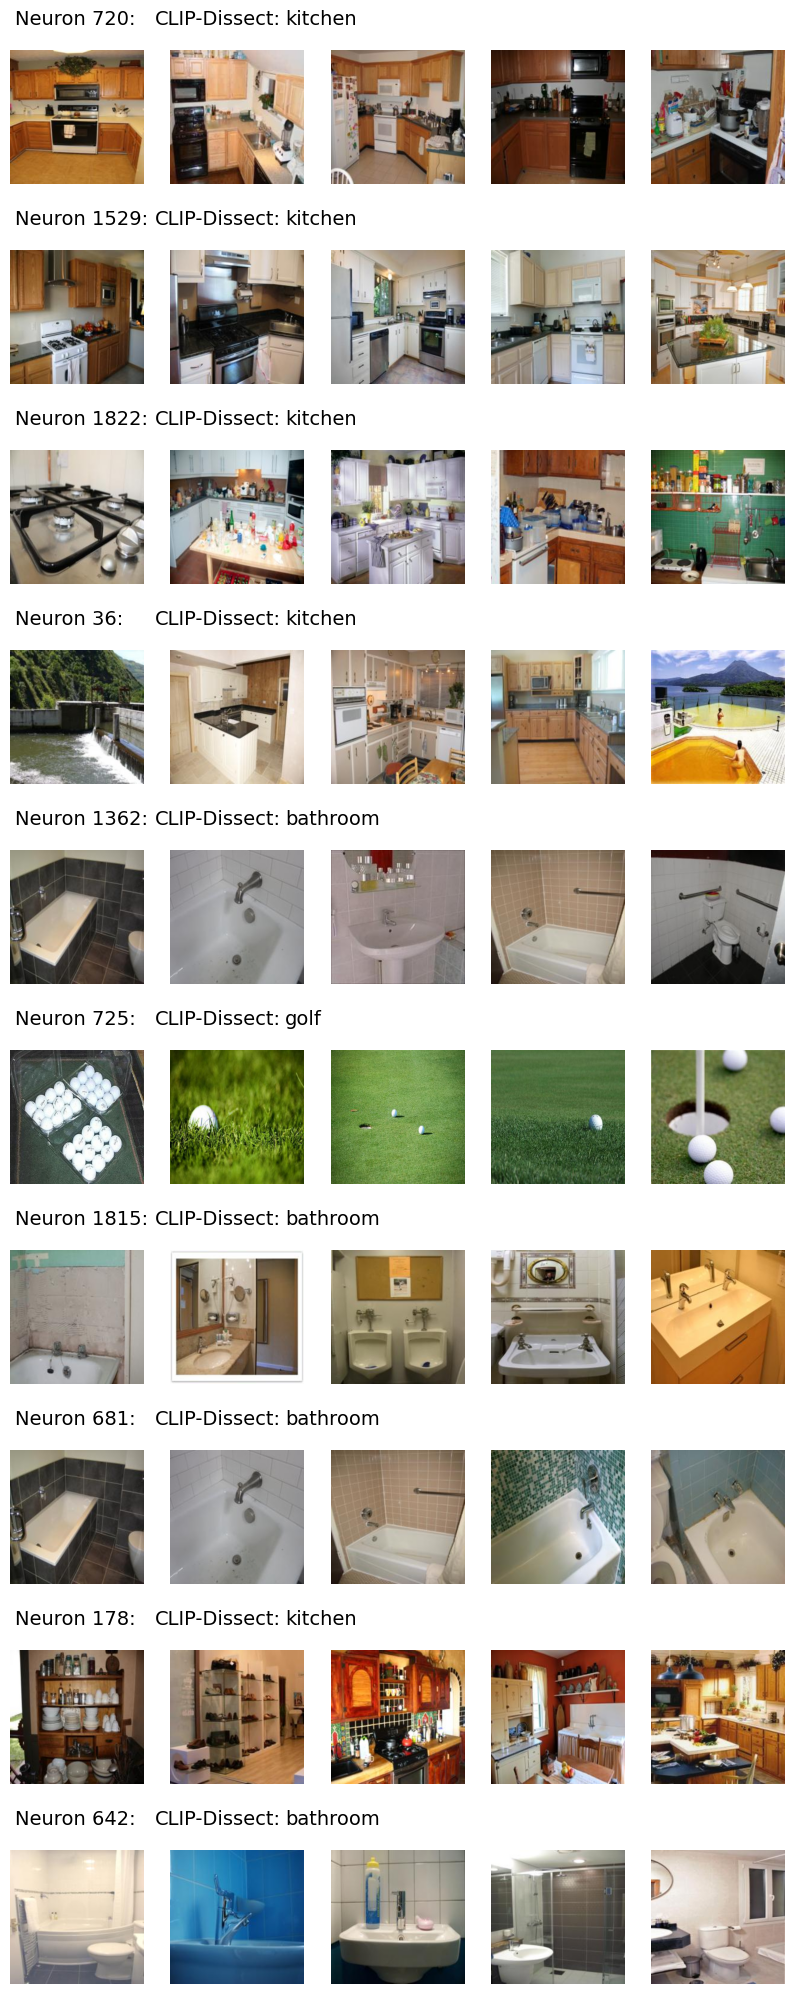

In [6]:
neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
font_size=14
font = {'size'   : font_size}

matplotlib.rc('font', **font)

fig = plt.figure(figsize=[10, len(neurons_to_check)*2])#constrained_layout=True)
subfigs = fig.subfigures(nrows=len(neurons_to_check), ncols=1)
for j, orig_id in enumerate(neurons_to_check):
    vals, ids = torch.topk(similarities[orig_id], k=5, largest=True)
        
    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "CLIP-Dissect:", size=font_size)
    subfig.text(0.4, 0.96, words[int(ids[0])], size=font_size)
    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        axs[i].imshow(im)
        axs[i].axis('off')
plt.show()